# Compare Spatiotemporal Linear Reconstructions for Visually Evoked vs Electrically Evoked Responses

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import rawmovie
import matplotlib.pyplot as plt
import os
import cvxpy as cp

In [45]:
# Modifed from ARG lnp.py functions

def get_frame_times(ttl_times,frames_per_ttl):
    """
    Linearly interpolates frame times based on the ttls

    Parameters:
        ttl_times: ttl times
        frames_per_ttl: frames per ttl
    
    Returns:
        Array of interpolated frame times.
    """

    frame_times = []

    for i in range(ttl_times.shape[0]-1):
        frame_times.append(np.linspace(ttl_times[i],
                               ttl_times[i+1],
                               frames_per_ttl,
                               endpoint=False))

    return np.asarray(frame_times).ravel()

def get_binned_spikes(vcd,cells):
    '''
    Parameters:
        vcd: Vision data table object
        cells: list of cells to compute STAs for
    Returns:
        A matrix of size frames by cells

    Bins the spike train using the (full resolution) frames of the monitor 
    as bin edges.
    '''
    frames_per_ttl = 60 # SUBJECT TO CHANGE

    # Get the interpolated frame times.
    ttl_times = vcd.ttl_times[40:] / 20000 * 1000 # ms # 40 is the first jittered natural scene SUBJECT TO CHANGE
    
    frame_times = get_frame_times(ttl_times,frames_per_ttl)

    # Set the bin edges as as the frame times with an additional fake frame.
    monitor_interval = 1 / 120 * 1000
    bin_edges = np.append(frame_times,frame_times[-1] +  monitor_interval)

    # Loop through cells and bin spike train.
    binned_spikes = []

    for cell in cells:
        spike_times = vcd.get_spike_times_for_cell(cell) / 20000 * 1000 # ms
        binned_spikes.append(np.histogram(spike_times,bins=bin_edges)[0])
    
    return np.asarray(binned_spikes).T

Paths

In [3]:
piece = '2024-07-18-0'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
label = ""

vstim_base = analysis_base
vstim = "data003_from_data001"
vstim_path = os.path.join(vstim_base, vstim)

In [4]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)
print(f"Total selective cells: {selective_cells_of_interest.size}")

Total selective cells: 53


In [5]:
vstim_vcd = vl.load_vision_data(vstim_path,vstim,
                                include_neurons=True)

In [6]:
binned_spikes = get_binned_spikes(vstim_vcd,selective_cells_of_interest)

In [7]:
print(binned_spikes.shape)

(29940, 53)


In [18]:
N = 60
M = binned_spikes.shape[0] - N + 1
R = np.zeros((M, 1 + N * binned_spikes.shape[1]))
for i in range(M):
    R[i,0] = 1
    R[i,1:] = binned_spikes[i:i+N].ravel(order='F') # column-major order
print(R.shape)

(29881, 3181)


In [25]:
imagenet = rawmovie.RawMovieReader(f"/Volumes/Data/Stimuli/imagenet/INbrownian/INbrownian_05s_2500_0A_045.rawMovie")
imagenet_frames, _ = imagenet.get_frame_sequence(0,50*60) 
imagenet_frames = imagenet_frames[:,:,:,0] # All color channels are the same
num_frames, pixels_y, pixels_x = imagenet_frames.shape
S = np.tile(imagenet_frames.reshape((num_frames,-1)), (10,1))[:M]
print(S.shape)

(29881, 51200)


In [46]:
test_indices = np.array([i for i in np.arange(M) if (i%3000) < 10*60])
train_indices = np.array([i for i in np.arange(M) if i not in test_indices])
R_train = R[train_indices]
S_train = S[train_indices]
R_test = R[test_indices]
S_test = S[test_indices]

In [47]:
f = np.linalg.inv(R_train.T@R_train)@R_train.T@S_train

In [48]:
u_train = R_train@f

In [49]:
u_test = R_test@f

In [35]:
print(R_train.shape)
print(f.shape)
print(S_train.shape)
print(u_train.shape)

(29881, 3181)
(3181, 51200)
(29881, 51200)
(29881, 51200)


In [52]:
print(R_test.shape)
print(S_test.shape)
print(u_test.shape)

(6000, 3181)
(6000, 51200)
(6000, 51200)


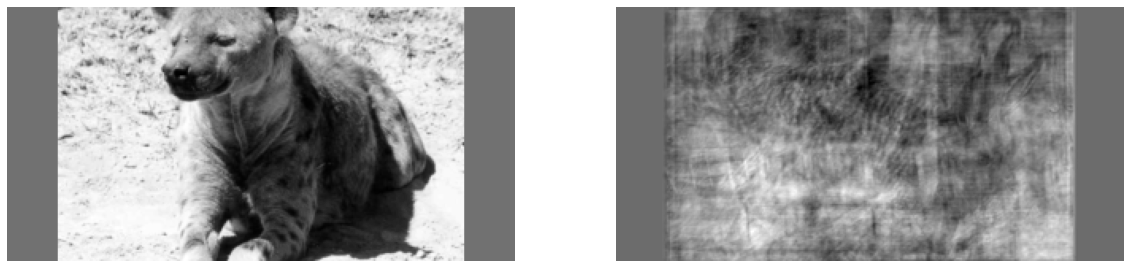

In [78]:
img_index = 2 * 60

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(imagenet_frames[img_index].reshape(pixels_y,pixels_x), cmap='gray')
ax[0].axis('off')
ax[1].imshow(u_test[img_index].reshape(pixels_y,pixels_x), cmap='gray')
ax[1].axis('off')
plt.show()